# FINAL PORTFOLIO PROJECT - REGRESSION
## Predicting Energy Production (MWh)
### 5CS037 - Concepts and Technologies of AI | Herald College

**Objective:** Predict Energy_Production_MWh from messy energy dataset
**Target Variable:** Energy_Production_MWh
**SDG Alignment:** SDG 7 - Affordable and Clean Energy

## TASK 1: EXPLORATORY DATA ANALYSIS (EDA)

### 1.1: Load and Inspect Dataset

In [7]:
# =============================================================================
# TASK 1: EXPLORATORY DATA ANALYSIS (EDA)
# 1.1: Load and Inspect Dataset
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Set random seed
np.random.seed(42)

# =============================================================================
# Load OWID Energy Dataset
# =============================================================================

df = pd.read_csv("/content/owid-energy-data.csv")

print("TASK 1.1: Dataset Inspection")
print("="*80)

print(f"Original Dataset Shape: {df.shape}")

# Select only useful columns for regression
selected_columns = [
    'country',
    'year',
    'population',
    'gdp',
    'primary_energy_consumption',
    'renewables_consumption',
    'coal_consumption',
    'oil_consumption',
    'gas_consumption',
    'solar_consumption',
    'wind_consumption',
    'hydro_consumption',
    'electricity_demand'
]

df = df[selected_columns]

print(f"\nSelected Dataset Shape: {df.shape}")

print("\nColumn Names and Data Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe(include='all'))

TASK 1.1: Dataset Inspection
Original Dataset Shape: (23377, 130)

Selected Dataset Shape: (23377, 13)

Column Names and Data Types:
country                        object
year                            int64
population                    float64
gdp                           float64
primary_energy_consumption    float64
renewables_consumption        float64
coal_consumption              float64
oil_consumption               float64
gas_consumption               float64
solar_consumption             float64
wind_consumption              float64
hydro_consumption             float64
electricity_demand            float64
dtype: object

First 5 Rows:
         country  year  population  gdp  primary_energy_consumption  \
0  ASEAN (Ember)  2000         NaN  NaN                         NaN   
1  ASEAN (Ember)  2001         NaN  NaN                         NaN   
2  ASEAN (Ember)  2002         NaN  NaN                         NaN   
3  ASEAN (Ember)  2003         NaN  NaN                     

,country,year,population,gdp,primary_energy_consumption,renewables_consumption,coal_consumption,oil_consumption,gas_consumption,solar_consumption,wind_consumption,hydro_consumption,electricity_demand
count,23377,23377.000000,1.889400e+04,1.178000e+04,13255.000000,6405.000000,6405.000000,6405.000000,6405.000000,6405.000000,6405.000000,6405.000000,6378.000000
unique,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,World,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1976.238611,1.058587e+08,4.257565e+11,4254.768667,513.739404,1682.740230,2304.061160,1284.206380,23.625814,48.691257,379.975274,647.694695
std,NaN,35.331092,4.720948e+08,3.507870e+12,14897.508937,1572.129560,5153.876458,6079.290687,3670.941632,179.415252,281.755752,1033.366729,2579.025996
min,NaN,1900.000000,1.776000e+03,1.642060e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1949.000000,1.599088e+06,1.426394e+10,8.002500,5.299000,4.349000,80.389000,11.881000,0.000000,0.000000,3.517000,1.540000
50%,NaN,1985.000000,6.951653e+06,4.357680e+10,91.187000,37.118000,47.364000,204.001000,82.809000,0.000000,0.000000,28.391000,12.460000
75%,NaN,2005.000000,2.581793e+07,1.830576e+11,772.244500,190.562000,446.305000,1013.222000,440.570000,0.094000,0.916000,157.449000,93.567500


### 1.2: Data Quality Assessment

In [8]:
# =============================================================================
# TASK 1.2: Data Quality Assessment & CLEANING
# =============================================================================

print("TASK 1.2: Data Quality Assessment & CLEANING")
print("="*80)

print(f"Total Records Before Cleaning: {len(df)}")

# Missing values summary
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
})

print("\nMissing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))

print("\nTotal Missing Values:", df.isnull().sum().sum())

# =============================================================================
# CLEANING
# =============================================================================

df_clean = df.copy()

# Remove duplicate rows
duplicates = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)

print("\n" + "="*80)
print("STEP 1: Duplicate Removal")
print("="*80)
print(f"Removed {duplicates} duplicate rows.")

# Remove rows where target is missing
before_rows = len(df_clean)
df_clean.dropna(subset=['electricity_demand'], inplace=True)

print("\nSTEP 2: Remove Missing Target Values")
print(f"Rows Removed: {before_rows - len(df_clean)}")

# Fill numeric columns with median
print("\nSTEP 3: Fill Missing Numeric Values (Median)")

numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if col != 'electricity_demand':
        missing = df_clean[col].isnull().sum()
        if missing > 0:
            median = df_clean[col].median()
            df_clean[col].fillna(median, inplace=True)
            print(f"{col}: Filled {missing} values with median = {median:.2f}")

# Fill country if missing
if df_clean['country'].isnull().sum() > 0:
    missing_country = df_clean['country'].isnull().sum()
    df_clean['country'].fillna("Unknown", inplace=True)
    print(f"\nFilled {missing_country} missing country values.")

# Final dataset
df = df_clean.copy()

print("\n" + "="*80)
print("CLEANING COMPLETE")
print("="*80)

print(f"Final Dataset Shape: {df.shape}")
print(f"Remaining Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\nFirst 5 Rows After Cleaning:")
display(df.head())

TASK 1.2: Data Quality Assessment & CLEANING
Total Records Before Cleaning: 23377

Missing Values Summary:
                    Column  Missing_Count  Missing_Percent
                population           4483        19.176969
                       gdp          11597        49.608590
primary_energy_consumption          10122        43.298969
    renewables_consumption          16972        72.601275
          coal_consumption          16972        72.601275
           oil_consumption          16972        72.601275
           gas_consumption          16972        72.601275
         solar_consumption          16972        72.601275
          wind_consumption          16972        72.601275
         hydro_consumption          16972        72.601275
        electricity_demand          16999        72.716773

Total Missing Values: 162005

STEP 1: Duplicate Removal
Removed 0 duplicate rows.

STEP 2: Remove Missing Target Values
Rows Removed: 16999

STEP 3: Fill Missing Numeric Values (Median

,country,year,population,gdp,primary_energy_consumption,renewables_consumption,coal_consumption,oil_consumption,gas_consumption,solar_consumption,wind_consumption,hydro_consumption,electricity_demand
0,ASEAN (Ember),2000,7390034.0,8.287077e+10,59.718,44.1725,58.26,211.5035,157.7245,0.048,0.5215,22.324,378.76
1,ASEAN (Ember),2001,7390034.0,8.287077e+10,59.718,44.1725,58.26,211.5035,157.7245,0.048,0.5215,22.324,405.09
2,ASEAN (Ember),2002,7390034.0,8.287077e+10,59.718,44.1725,58.26,211.5035,157.7245,0.048,0.5215,22.324,433.19
3,ASEAN (Ember),2003,7390034.0,8.287077e+10,59.718,44.1725,58.26,211.5035,157.7245,0.048,0.5215,22.324,458.30
4,ASEAN (Ember),2004,7390034.0,8.287077e+10,59.718,44.1725,58.26,211.5035,157.7245,0.048,0.5215,22.324,496.61


In [9]:
print(df.shape)

(6378, 13)


### 1.3: Statistical Analysis & Visualizations

In [ ]:
# =============================================================================
# TASK 1.3: Statistical Analysis
# =============================================================================

print("TASK 1.3: Statistical Analysis")
print("="*80)

# Distribution of Target Variable
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['electricity_demand'].hist(bins=40, edgecolor='black')
plt.title('Distribution of Electricity Demand', fontsize=12, fontweight='bold')
plt.xlabel('Electricity Demand (TWh)')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.boxplot(y=df['electricity_demand'])
plt.title('Box Plot - Electricity Demand', fontsize=12, fontweight='bold')
plt.ylabel('Electricity Demand (TWh)')

plt.tight_layout()
plt.savefig('02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTarget Variable Statistics:")
print(f"Mean      : {df['electricity_demand'].mean():.2f}")
print(f"Median    : {df['electricity_demand'].median():.2f}")
print(f"Std Dev   : {df['electricity_demand'].std():.2f}")
print(f"Minimum   : {df['electricity_demand'].min():.2f}")
print(f"Maximum   : {df['electricity_demand'].max():.2f}")

# =============================================================================
# Correlation Analysis
# =============================================================================

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("03_correlation_heatmap.png", dpi=300)
plt.show()

print("\nTop Features Correlated with Electricity Demand:")

corr_target = corr['electricity_demand'].sort_values(ascending=False)

print(corr_target)

## TASK 2: NEURAL NETWORK MODEL

TASK 2: Neural Network Model - Multi-Layer Perceptron
Training set size: 5102
Test set size: 1276
Number of features: 11

Training Neural Network...

Neural Network Results:
Training MSE : 2742272.6330
Test MSE     : 3613423.7405
Training RMSE: 1655.9809
Test RMSE    : 1900.9008
Training MAE : 481.7692
Test MAE     : 509.7536
Training R²  : 0.5805
Test R²      : 0.4909


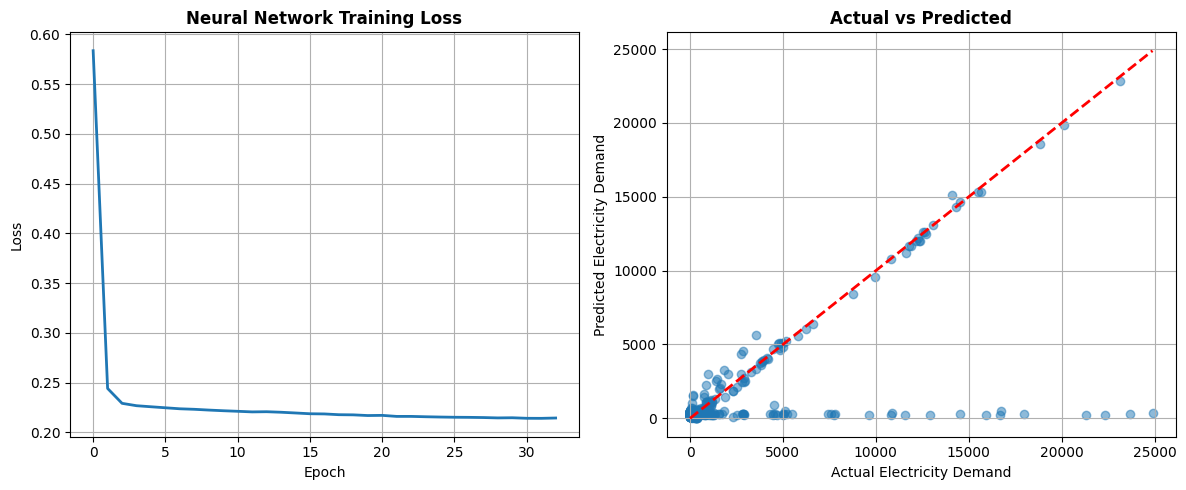

In [10]:
# =============================================================================
# TASK 2: Neural Network Model - Multi-Layer Perceptron
# =============================================================================

print("TASK 2: Neural Network Model - Multi-Layer Perceptron")
print("="*80)

# Features and Target
X = df.drop(columns=['electricity_demand', 'country'])
y = df['electricity_demand']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale Features
X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

# Scale Target
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1,1)
).ravel()

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1,1)
).ravel()

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

# =============================================================================
# Build Neural Network
# =============================================================================

nn_model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

print("\nTraining Neural Network...")

nn_model.fit(
    X_train_scaled,
    y_train_scaled
)

# =============================================================================
# Predictions
# =============================================================================

train_pred_scaled = nn_model.predict(X_train_scaled)
test_pred_scaled = nn_model.predict(X_test_scaled)

train_pred_nn = y_scaler.inverse_transform(
    train_pred_scaled.reshape(-1,1)
).ravel()

test_pred_nn = y_scaler.inverse_transform(
    test_pred_scaled.reshape(-1,1)
).ravel()

# =============================================================================
# Evaluation
# =============================================================================

train_mse_nn = mean_squared_error(y_train, train_pred_nn)
test_mse_nn = mean_squared_error(y_test, test_pred_nn)

train_rmse_nn = np.sqrt(train_mse_nn)
test_rmse_nn = np.sqrt(test_mse_nn)

train_mae_nn = mean_absolute_error(y_train, train_pred_nn)
test_mae_nn = mean_absolute_error(y_test, test_pred_nn)

train_r2_nn = r2_score(y_train, train_pred_nn)
test_r2_nn = r2_score(y_test, test_pred_nn)

print("\nNeural Network Results:")

print(f"Training MSE : {train_mse_nn:.4f}")
print(f"Test MSE     : {test_mse_nn:.4f}")

print(f"Training RMSE: {train_rmse_nn:.4f}")
print(f"Test RMSE    : {test_rmse_nn:.4f}")

print(f"Training MAE : {train_mae_nn:.4f}")
print(f"Test MAE     : {test_mae_nn:.4f}")

print(f"Training R²  : {train_r2_nn:.4f}")
print(f"Test R²      : {test_r2_nn:.4f}")

# =============================================================================
# Visualizations
# =============================================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(nn_model.loss_curve_, linewidth=2)

plt.title("Neural Network Training Loss", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)

plt.scatter(y_test, test_pred_nn, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("Actual vs Predicted", fontsize=12, fontweight='bold')
plt.xlabel("Actual Electricity Demand")
plt.ylabel("Predicted Electricity Demand")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "03_neural_network.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## TASK 3: PRIMARY MODELS
### Model 1: Ridge Regression
### Model 2: Random Forest Regressor

In [11]:
# =============================================================================
# TASK 3: PRIMARY MODELS
# =============================================================================

print("TASK 3: PRIMARY MODELS")
print("="*80)

# =============================================================================
# 3.1 Ridge Regression
# =============================================================================

print("\n3.1: Ridge Regression Model")
print("-"*80)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

ridge_train_mse = mean_squared_error(y_train, ridge_train_pred)
ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)

ridge_train_rmse = np.sqrt(ridge_train_mse)
ridge_test_rmse = np.sqrt(ridge_test_mse)

ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print("Ridge Regression Metrics:")
print(f"  Training MSE: {ridge_train_mse:.4f} | Test MSE: {ridge_test_mse:.4f}")
print(f"  Training RMSE: {ridge_train_rmse:.4f} | Test RMSE: {ridge_test_rmse:.4f}")
print(f"  Training MAE: {ridge_train_mae:.4f} | Test MAE: {ridge_test_mae:.4f}")
print(f"  Training R²: {ridge_train_r2:.4f} | Test R²: {ridge_test_r2:.4f}")

# =============================================================================
# 3.2 Random Forest Regressor
# =============================================================================

print("\n3.2: Random Forest Regressor Model")
print("-"*80)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)

rf_train_rmse = np.sqrt(rf_train_mse)
rf_test_rmse = np.sqrt(rf_test_mse)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Metrics:")
print(f"  Training MSE: {rf_train_mse:.4f} | Test MSE: {rf_test_mse:.4f}")
print(f"  Training RMSE: {rf_train_rmse:.4f} | Test RMSE: {rf_test_rmse:.4f}")
print(f"  Training MAE: {rf_train_mae:.4f} | Test MAE: {rf_test_mae:.4f}")
print(f"  Training R²: {rf_train_r2:.4f} | Test R²: {rf_test_r2:.4f}")

TASK 3: PRIMARY MODELS

3.1: Ridge Regression Model
--------------------------------------------------------------------------------
Ridge Regression Metrics:
  Training MSE: 2874762.8877 | Test MSE: 3626770.4935
  Training RMSE: 1695.5126 | Test RMSE: 1904.4082
  Training MAE: 537.3899 | Test MAE: 559.6373
  Training R²: 0.5603 | Test R²: 0.4890

3.2: Random Forest Regressor Model
--------------------------------------------------------------------------------
Random Forest Metrics:
  Training MSE: 1427305.7613 | Test MSE: 2557374.9931
  Training RMSE: 1194.6990 | Test RMSE: 1599.1795
  Training MAE: 213.4130 | Test MAE: 305.7325
  Training R²: 0.7817 | Test R²: 0.6397


## TASK 4: HYPERPARAMETER OPTIMIZATION
### GridSearchCV with 5-Fold Cross-Validation

In [12]:
# =============================================================================
# TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV
# =============================================================================

print("TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV")
print("="*80)

# =============================================================================
# 4.1 Ridge Regression Hyperparameter Tuning
# =============================================================================

print("\n4.1: Ridge Regression - Hyperparameter Tuning")
print("-"*80)

ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

print(f"Best Ridge Alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best Ridge CV Score (R²): {ridge_grid.best_score_:.4f}")

# =============================================================================
# 4.2 Random Forest Hyperparameter Tuning
# =============================================================================

print("\n4.2: Random Forest - Hyperparameter Tuning")
print("-"*80)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Random Forest uses ORIGINAL features (not scaled)
rf_grid.fit(X_train, y_train)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV Score (R²): {rf_grid.best_score_:.4f}")

print("\nGridSearch Results Summary:")
print(f"  Ridge Best CV R² : {ridge_grid.best_score_:.4f}")
print(f"  Random Forest Best CV R² : {rf_grid.best_score_:.4f}")

TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV

4.1: Ridge Regression - Hyperparameter Tuning
--------------------------------------------------------------------------------
Best Ridge Alpha: 100
Best Ridge CV Score (R²): 0.5423

4.2: Random Forest - Hyperparameter Tuning
--------------------------------------------------------------------------------
Best RF Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best RF CV Score (R²): 0.7138

GridSearch Results Summary:
  Ridge Best CV R² : 0.5423
  Random Forest Best CV R² : 0.7138


## TASK 5: FEATURE SELECTION
### SelectKBest Filter Method

TASK 5: FEATURE SELECTION with SelectKBest

Original Number of Features: 11
Selected Number of Features: 11

Selected Features:
1. year
2. population
3. gdp
4. primary_energy_consumption
5. renewables_consumption
6. coal_consumption
7. oil_consumption
8. gas_consumption
9. solar_consumption
10. wind_consumption
11. hydro_consumption

Top Feature Importance Scores:
                       Feature        Score
3   primary_energy_consumption  6171.026956
6              oil_consumption  5786.234105
10           hydro_consumption  5681.451402
4       renewables_consumption  5634.758767
7              gas_consumption  5581.042204
5             coal_consumption  4846.216300
1                   population  4657.409885
9             wind_consumption  3208.135366
8            solar_consumption  1992.043845
2                          gdp  1228.778599
0                         year    19.148779


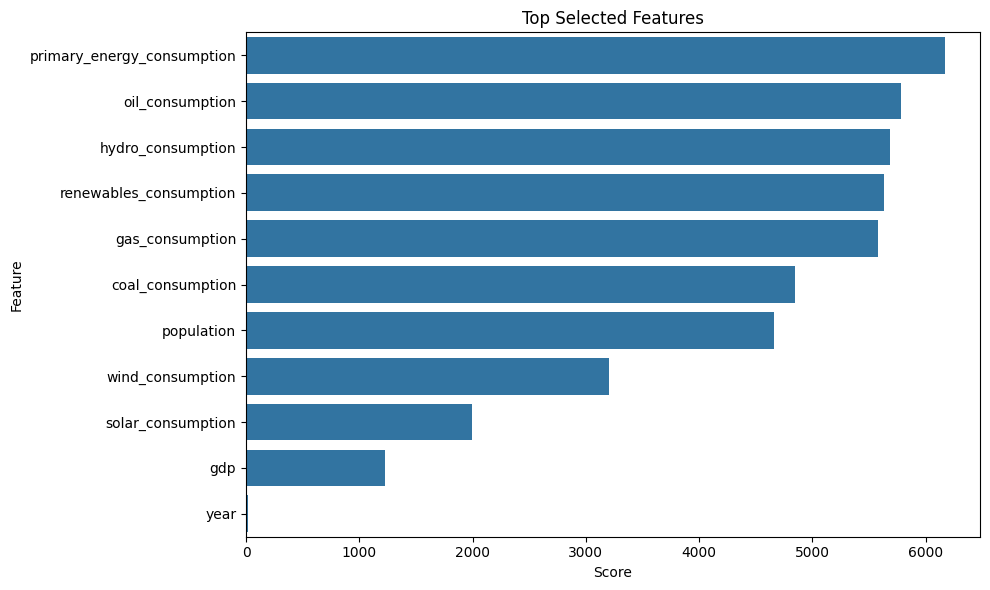

In [13]:
# =============================================================================
# TASK 5: FEATURE SELECTION with SelectKBest
# =============================================================================

print("TASK 5: FEATURE SELECTION with SelectKBest")
print("="*80)

# Select top features
k_features = min(15, X_train_scaled.shape[1])

selector = SelectKBest(
    score_func=f_regression,
    k=k_features
)

selector.fit(X_train_scaled, y_train)

# Selected feature names
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]

print(f"\nOriginal Number of Features: {X_train_scaled.shape[1]}")
print(f"Selected Number of Features: {k_features}")

print("\nSelected Features:")

for i, feature in enumerate(selected_features,1):
    print(f"{i}. {feature}")

# Feature Scores
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print("\nTop Feature Importance Scores:")

print(feature_scores.head(20))

# Plot Top 15 Features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_scores.head(15),
    x="Score",
    y="Feature"
)

plt.title("Top Selected Features")
plt.tight_layout()

plt.savefig(
    "04_feature_selection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Transform datasets
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

## TASK 6: FINAL MODELS with Optimized Hyperparameters

TASK 6: FINAL MODELS with Optimized Hyperparameters

FINAL MODEL COMPARISON
              Model     Train MSE      Test MSE   Train RMSE    Test RMSE  \
0  Ridge Regression  2.880749e+06  3.632843e+06  1697.276855  1906.001945   
1     Random Forest  1.375414e+06  2.553073e+06  1172.780414  1597.833820   

    Train MAE    Test MAE  Train R²   Test R²  
0  534.809745  559.638359  0.559344  0.488187  
1  210.092603  306.741727  0.789609  0.640310  

*** BEST MODEL ***
Random Forest
Test R² : 0.6403


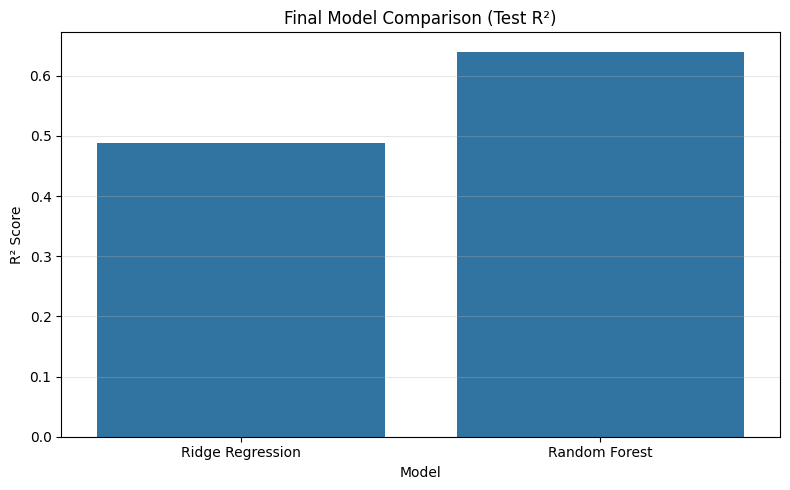

In [14]:
# =============================================================================
# TASK 6: FINAL MODELS with Optimized Hyperparameters
# =============================================================================

print("TASK 6: FINAL MODELS with Optimized Hyperparameters")
print("="*80)

# =============================================================================
# Final Ridge Regression
# =============================================================================

final_ridge = Ridge(
    alpha=ridge_grid.best_params_['alpha']
)

final_ridge.fit(X_train_selected, y_train)

# =============================================================================
# Final Random Forest
# =============================================================================

final_rf = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    min_samples_leaf=rf_grid.best_params_['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_selected, y_train)

# =============================================================================
# Predictions
# =============================================================================

ridge_train_pred = final_ridge.predict(X_train_selected)
ridge_test_pred = final_ridge.predict(X_test_selected)

rf_train_pred = final_rf.predict(X_train_selected)
rf_test_pred = final_rf.predict(X_test_selected)

# =============================================================================
# Results Table
# =============================================================================

results = pd.DataFrame({

    "Model":[
        "Ridge Regression",
        "Random Forest"
    ],

    "Train MSE":[
        mean_squared_error(y_train,ridge_train_pred),
        mean_squared_error(y_train,rf_train_pred)
    ],

    "Test MSE":[
        mean_squared_error(y_test,ridge_test_pred),
        mean_squared_error(y_test,rf_test_pred)
    ],

    "Train RMSE":[
        np.sqrt(mean_squared_error(y_train,ridge_train_pred)),
        np.sqrt(mean_squared_error(y_train,rf_train_pred))
    ],

    "Test RMSE":[
        np.sqrt(mean_squared_error(y_test,ridge_test_pred)),
        np.sqrt(mean_squared_error(y_test,rf_test_pred))
    ],

    "Train MAE":[
        mean_absolute_error(y_train,ridge_train_pred),
        mean_absolute_error(y_train,rf_train_pred)
    ],

    "Test MAE":[
        mean_absolute_error(y_test,ridge_test_pred),
        mean_absolute_error(y_test,rf_test_pred)
    ],

    "Train R²":[
        r2_score(y_train,ridge_train_pred),
        r2_score(y_train,rf_train_pred)
    ],

    "Test R²":[
        r2_score(y_test,ridge_test_pred),
        r2_score(y_test,rf_test_pred)
    ]

})

print("\nFINAL MODEL COMPARISON")
print("="*80)

print(results)

# =============================================================================
# Best Model
# =============================================================================

best_idx = results["Test R²"].idxmax()

print("\n*** BEST MODEL ***")
print(results.loc[best_idx,"Model"])

print(f"Test R² : {results.loc[best_idx,'Test R²']:.4f}")

# =============================================================================
# Visualization
# =============================================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Test R²"
)

plt.title("Final Model Comparison (Test R²)")
plt.ylabel("R² Score")

plt.grid(axis='y',alpha=0.3)

plt.tight_layout()

plt.savefig(
    "05_final_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()